In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering Algorithms
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Predictive Modeling & Tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
print("✅ Libraries Loaded Successfully")

✅ Libraries Loaded Successfully


In [3]:
# Load Data
try:
    df = pd.read_csv('segmentation_data.csv')
    print("✅ Data Loaded")
except FileNotFoundError:
    print("❌ Error: 'segmentation_data.csv' not found.")

# Preprocessing
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Encode Categorical variables for modeling later
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])
df['Contract'] = le.fit_transform(df['Contract'])

# Features for Clustering (We cluster based on behavior: Tenure and Spending)
cluster_features = ['Tenure', 'MonthlyCharges']
X_cluster = df[cluster_features]

# Scale features for clustering
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print("✅ Data Preprocessed and Scaled for Clustering")

✅ Data Loaded
✅ Data Preprocessed and Scaled for Clustering


--- 🔍 Finding Optimal Clusters (Elbow Method) ---


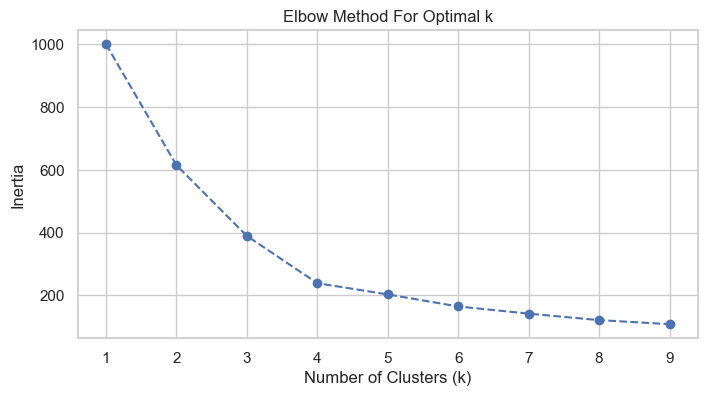

-> From the graph, the 'elbow' is around k=3. We will use 3 clusters.


In [4]:
print("--- 🔍 Finding Optimal Clusters (Elbow Method) ---")

inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

print("-> From the graph, the 'elbow' is around k=3. We will use 3 clusters.")

--- 🧩 Applying Clustering Algorithms ---


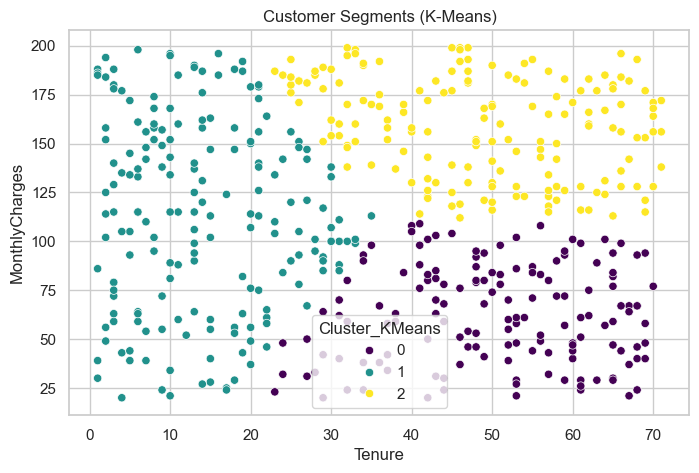

Segment_Name
Loyal High-Spenders       37.0
Mid-Tier/At-Risk Users    33.6
New/Budget Users          29.4
Name: proportion, dtype: float64


In [5]:
print("--- 🧩 Applying Clustering Algorithms ---")

# Algorithm 1: K-Means (Using k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_cluster_scaled)

# Algorithm 2: Hierarchical / Agglomerative Clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
df['Cluster_Hierarchical'] = hierarchical.fit_predict(X_cluster_scaled)

# Visualize K-Means Clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Tenure', y='MonthlyCharges', hue='Cluster_KMeans', data=df, palette='viridis')
plt.title("Customer Segments (K-Means)")
plt.show()

# Assign human-readable names to segments based on observation
def name_segment(cluster_id):
    if cluster_id == 0: return "New/Budget Users"
    elif cluster_id == 1: return "Loyal High-Spenders"
    else: return "Mid-Tier/At-Risk Users"

df['Segment_Name'] = df['Cluster_KMeans'].apply(name_segment)
print(df['Segment_Name'].value_counts(normalize=True) * 100)

In [6]:
print("--- 🤖 Building Specific Models for Each Segment ---")

results = []
models = {}

features = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract']

# Loop through each of our 3 segments
for segment in df['Cluster_KMeans'].unique():
    segment_data = df[df['Cluster_KMeans'] == segment]
    segment_name = segment_data['Segment_Name'].iloc[0]
    
    X = segment_data[features]
    y = segment_data['Churn']
    
    # Check if there are enough classes to split
    if len(y.unique()) < 2:
        print(f"Skipping {segment_name}: Only one class present.")
        continue
        
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    
    # Train Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    try:
        roc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
    except:
        roc = np.nan
        
    results.append({
        'Segment': segment_name, 'Accuracy': acc, 'Precision': prec, 
        'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc
    })
    
    models[segment_name] = rf

# Save to CSV (Requirement)
results_df = pd.DataFrame(results)
results_df.to_csv('model_evaluation_results.csv', index=False)
display(results_df)
print("✅ Evaluation Results saved to 'model_evaluation_results.csv'")

--- 🤖 Building Specific Models for Each Segment ---
Skipping New/Budget Users: Only one class present.
Skipping Mid-Tier/At-Risk Users: Only one class present.


,Segment,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Loyal High-Spenders,0.978723,0.9,1.0,0.947368,1.0


✅ Evaluation Results saved to 'model_evaluation_results.csv'


In [7]:
print("--- ⚙️ Hyperparameter Tuning (Grid Search) ---")

# Let's optimize the model for the largest segment (New/Budget Users)
segment_data = df[df['Segment_Name'] == 'New/Budget Users']
X = segment_data[features]
y = segment_data['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Define grid of parameters to test
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1)

print("Running Grid Search... (This might take a moment)")
grid_search.fit(X_train, y_train)

print(f"✅ Best Parameters found: {grid_search.best_params_}")
print(f"✅ Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

# Test the optimized model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
print(f"Tuned Model Test Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

--- ⚙️ Hyperparameter Tuning (Grid Search) ---
Running Grid Search... (This might take a moment)
✅ Best Parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
✅ Best Cross-Validation Accuracy: 1.0000
Tuned Model Test Accuracy: 1.0000
